In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import scipy
import scipy.ndimage
import torch
from tqdm import tqdm

from grid_pattern_formation.evals.core import build_eval_context, get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import _compute_phase_order, _compute_jmean, _compute_phase_original_order
from grid_pattern_formation.evals.analysis_dynamics import get_fourier_spectrum, find_peak_coordinates
from grid_pattern_formation.evals.analysis_core import compute_grid_scores
from grid_pattern_formation.utils.two_d_sort import get_2d_sort

%matplotlib inline

plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
})

In [ ]:
baseline_ctx = build_eval_context(
    checkpoint_path="../checkpoints/baseline_final.pth",
    config_path="../configs/replicate_baseline.yaml",
    results_root="../results/phase_analysis",
)
topo_ctx = build_eval_context(
    checkpoint_path="../checkpoints/cos_decay_hw4_final_model.pth",
    config_path="../configs/topo_cos_decay_hw4.yaml",
    results_root="../results/phase_analysis",
)

RES = 50
N_AVG = 100
Ng = 4096
n = int(np.sqrt(Ng))

print("Baseline ratemaps")
baseline_act, baseline_rm, baseline_g, baseline_pos = get_cached_ratemaps(baseline_ctx, res=RES, n_avg=N_AVG, ng=Ng)
print("Topoloss ratemaps")
topo_act, topo_rm, topo_g, topo_pos = get_cached_ratemaps(topo_ctx, res=RES, n_avg=N_AVG, ng=Ng)

baseline_order, baseline_phases = _compute_phase_order(baseline_ctx, baseline_rm, RES)
topo_order, topo_phases = _compute_phase_original_order(topo_ctx, topo_rm, RES)

baseline_phases_sorted = baseline_phases[:, baseline_order]

J_baseline = baseline_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T
J_topo = topo_ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T

J_baseline_sorted = J_baseline[baseline_order][:, baseline_order]

print("Baseline grid scores")
baseline_scores = compute_grid_scores(baseline_ctx)
print("Topoloss grid scores")
topo_scores = compute_grid_scores(topo_ctx)

Baseline ratemaps
Topoloss ratemaps
Baseline grid scores


Grid scores:   0%|          | 0/4096 [00:00<?, ?it/s]/Volumes/LaCie SSD/Documents/MurtyLab/grid-pattern-formation/grid_pattern_formation/evals/grid_scores.py:115: RuntimeWarning: invalid value encountered in divide
  x_coef = np.divide(covar, np.multiply(std_seq1, std_seq2))
Grid scores: 100%|██████████| 4096/4096 [00:11<00:00, 349.72it/s]


Topoloss grid scores


Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 340.10it/s]


In [3]:
def circular_diff(a, b):
    d = a - b
    return (d + np.pi) % (2 * np.pi) - np.pi

def phase_gradient_magnitude(phases_1d, side):
    sheet = phases_1d.reshape(side, side)
    dx = circular_diff(sheet, np.roll(sheet, 1, axis=1))
    dy = circular_diff(sheet, np.roll(sheet, 1, axis=0))
    return np.sqrt(dx**2 + dy**2)

def phase_autocorrelation(phases_1d, side, max_lag=20):
    sheet = phases_1d.reshape(side, side)
    autocorr = np.zeros(max_lag)
    for lag in range(1, max_lag + 1):
        cos_diff_x = np.cos(circular_diff(sheet, np.roll(sheet, lag, axis=1))).mean()
        cos_diff_y = np.cos(circular_diff(sheet, np.roll(sheet, lag, axis=0))).mean()
        autocorr[lag - 1] = (cos_diff_x + cos_diff_y) / 2
    return autocorr

def radial_profile(jmean, max_r=None):
    center = np.array(jmean.shape) // 2
    Y, X = np.ogrid[:jmean.shape[0], :jmean.shape[1]]
    r = np.sqrt((X - center[1])**2 + (Y - center[0])**2).astype(int)
    if max_r is None:
        max_r = min(center)
    radial = np.zeros(max_r)
    for ri in range(max_r):
        mask = r == ri
        if mask.sum() > 0:
            radial[ri] = jmean[mask].mean()
    return radial

A_hex = np.asarray([[2, 1], [0, np.sqrt(3)]]) / 2
A_hex_inv = np.linalg.inv(A_hex)

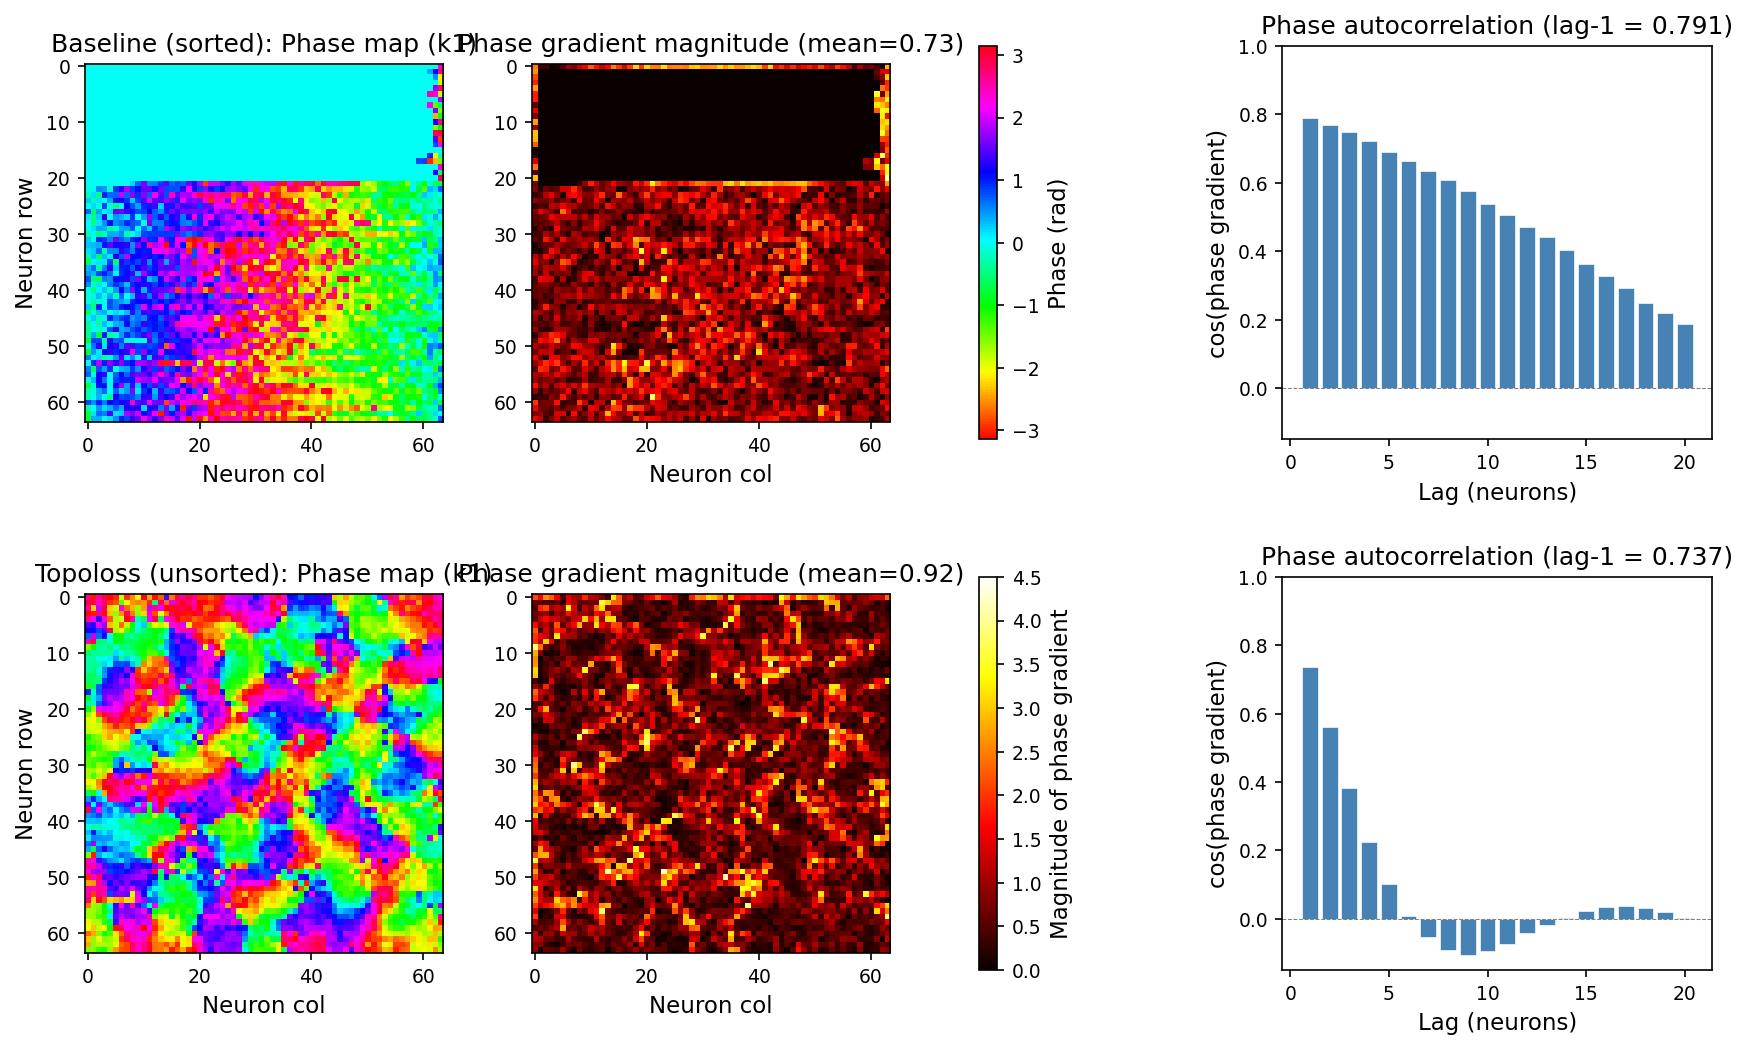

In [4]:
fig = plt.figure(figsize=(14, 8))
gs = gridspec.GridSpec(2, 5, width_ratios=[1, 1, 0.05, 0.3, 1.2], wspace=0.35, hspace=0.35)

mode_idx = 0 # k1

for row, (label, phases) in enumerate([
    ("Baseline (sorted)", baseline_phases_sorted),
    ("Topoloss (unsorted)", topo_phases),
]):
    phase_sheet = phases[mode_idx].reshape(n, n)
    grad_mag = phase_gradient_magnitude(phases[mode_idx], n)
    autocorr = phase_autocorrelation(phases[mode_idx], n, max_lag=20)

    # Phase map
    ax0 = fig.add_subplot(gs[row, 0])
    im0 = ax0.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    ax0.set_title(f"{label}: Phase map (k1)")
    ax0.set_ylabel("Neuron row")
    ax0.set_xlabel("Neuron col")

    # Gradient magnitude
    ax1 = fig.add_subplot(gs[row, 1])
    im1 = ax1.imshow(grad_mag, cmap="hot", vmin=0, vmax=4.5)
    ax1.set_title(f"Phase gradient magnitude (mean={grad_mag.mean():.2f})")
    ax1.set_xlabel("Neuron col")

    # Autocorrelation
    ax2 = fig.add_subplot(gs[row, 4])
    ax2.bar(range(1, 21), autocorr, color="steelblue", edgecolor="white", linewidth=0.3)
    ax2.axhline(0, color="gray", linestyle="--", linewidth=0.5)
    ax2.set_xlabel("Lag (neurons)")
    ax2.set_ylabel("cos(phase gradient)")
    ax2.set_title(f"Phase autocorrelation (lag-1 = {autocorr[0]:.3f})")
    ax2.set_ylim([-0.15, 1.0])

# Colorbars
cax0 = fig.add_subplot(gs[0, 2])
plt.colorbar(im0, cax=cax0, label="Phase (rad)")
cax1 = fig.add_subplot(gs[1, 2])
plt.colorbar(im1, cax=cax1, label="Magnitude of phase gradient")

plt.show()

In [5]:
from scipy.ndimage import minimum_filter

def find_grid_patches(scores, n, n_patches=3, patch_size=5, min_gap=6):
    score_sheet = scores.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=patch_size, mode="wrap")
    patch_scores = min_score_map.ravel()
    best_patch_idx = np.argsort(patch_scores)[::-1]
    
    patch_centers = []
    for idx in best_patch_idx:
        cy, cx = np.unravel_index(idx, (n, n))
        overlap = False
        for py, px in patch_centers:
            dy = min(abs(cy - py), n - abs(cy - py))
            dx = min(abs(cx - px), n - abs(cx - px))
            if dy < min_gap and dx < min_gap:
                overlap = True
                break
        if not overlap:
            patch_centers.append((cy, cx))
            if len(patch_centers) >= n_patches:
                break
    return patch_centers

topo_score60 = topo_scores["score_60"]
topo_patches = find_grid_patches(topo_score60, n)

baseline_score60 = baseline_scores["score_60"]
baseline_score60_sorted = baseline_score60[baseline_order]
baseline_patches = find_grid_patches(baseline_score60_sorted, n)

baseline_act_sorted = baseline_act[baseline_order]

print("Topoloss patches (unsorted sheet):")
for i, (cy, cx) in enumerate(topo_patches):
    score_sheet = topo_score60.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=5, mode="wrap")
    print(f"Patch {i+1}: center=({cy},{cx}), min score = {min_score_map[cy, cx]:.3f}")

print("\nBaseline patches (sorted sheet):")
for i, (cy, cx) in enumerate(baseline_patches):
    score_sheet = baseline_score60_sorted.reshape(n, n)
    min_score_map = minimum_filter(score_sheet, size=5, mode="wrap")
    print(f"Patch {i+1}: center=({cy},{cx}), min score = {min_score_map[cy, cx]:.3f}")

Topoloss patches (unsorted sheet):
Patch 1: center=(13,23), min score = 0.763
Patch 2: center=(18,9), min score = 0.738
Patch 3: center=(53,15), min score = 0.716

Baseline patches (sorted sheet):
Patch 1: center=(36,49), min score = 0.148
Patch 2: center=(43,49), min score = 0.117
Patch 3: center=(29,55), min score = 0.110


Text(0.5, 0.95, 'Phase Shifts')

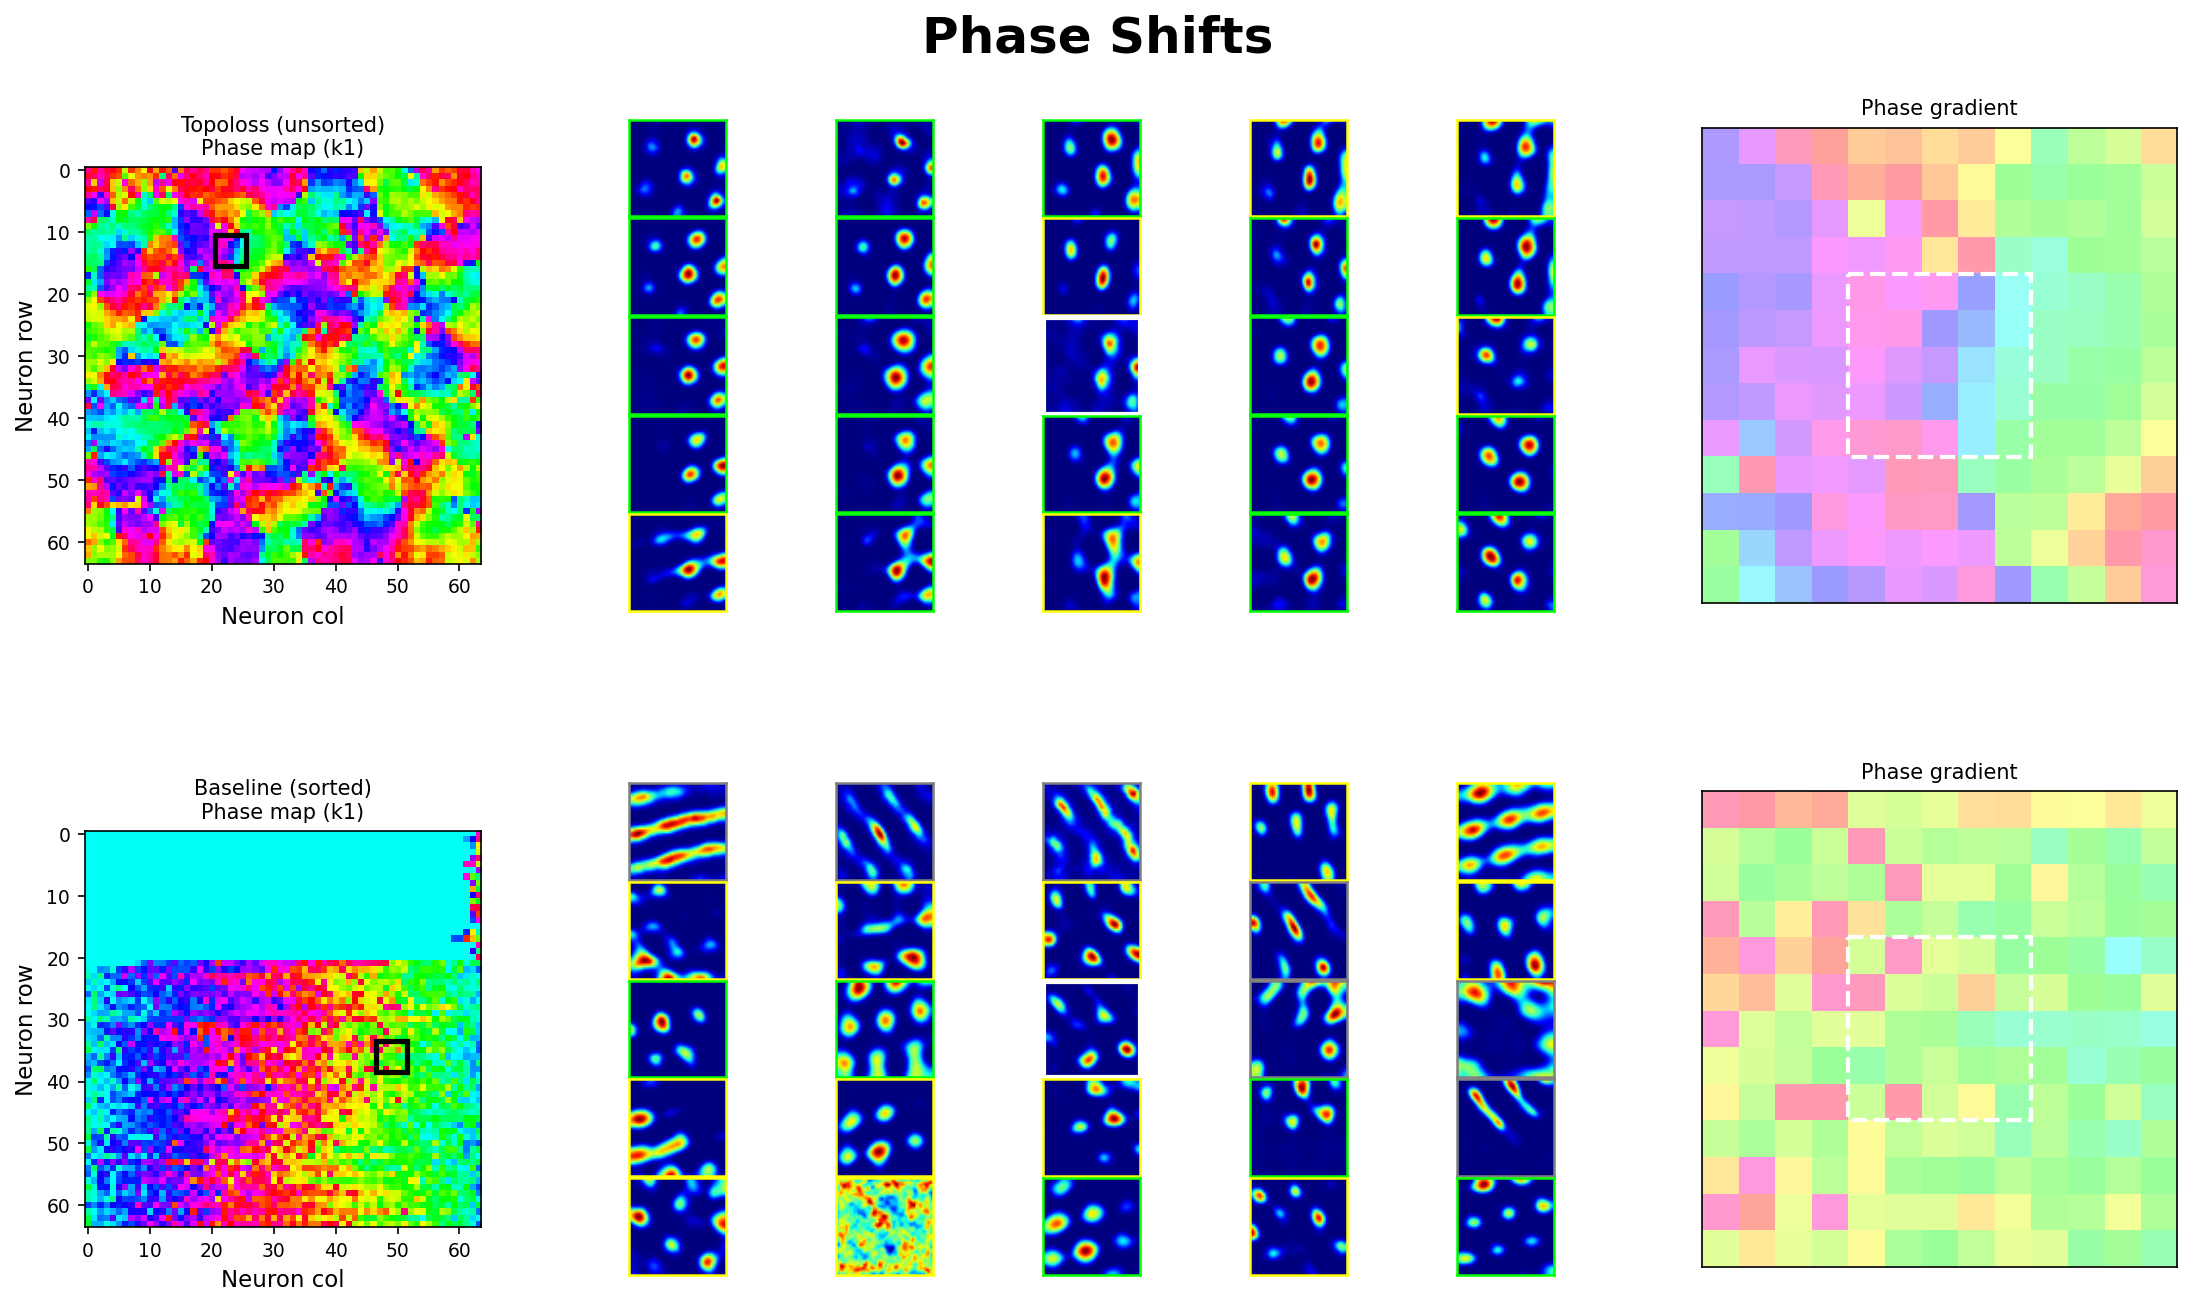

In [6]:
import cv2

patch_size = 5

fig = plt.figure(figsize=(18, 10))
outer_gs = gridspec.GridSpec(2, 3, width_ratios=[0.5, 1.3, 0.6], wspace=0.15, hspace=0.35)

for row, (model_label, patches, scores, act, phases, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, topo_phases, "C1"),
    ("Baseline (sorted)", baseline_patches, baseline_score60_sorted, baseline_act_sorted, baseline_phases_sorted, "C0"),
]):
    cy, cx = patches[0]
    score_sheet = scores.reshape(n, n)
    
    ax_phase = fig.add_subplot(outer_gs[row, 0])
    phase_sheet = phases[0].reshape(n, n)
    ax_phase.imshow(phase_sheet, cmap="hsv", vmin=-np.pi, vmax=np.pi)
    
    from matplotlib.patches import Rectangle
    rect = Rectangle(
        (cx - patch_size // 2 - 0.5, cy - patch_size // 2 - 0.5),
        patch_size, patch_size,
        linewidth=2.5, edgecolor="black", facecolor="none"
    )
    ax_phase.add_patch(rect)
    ax_phase.set_title(f"{model_label}\nPhase map (k1)", fontsize=10)
    ax_phase.set_xlabel("Neuron col")
    ax_phase.set_ylabel("Neuron row")
    
    rate_gs = gridspec.GridSpecFromSubplotSpec(
        patch_size, patch_size, subplot_spec=outer_gs[row, 1],
        wspace=0.02, hspace=0.02
    )
    for di in range(patch_size):
        for dj in range(patch_size):
            row_idx = (cy - patch_size // 2 + di) % n
            col_idx = (cx - patch_size // 2 + dj) % n
            neuron_idx = row_idx * n + col_idx
            ax_rm = fig.add_subplot(rate_gs[di, dj])
            rm = act[neuron_idx]
            rm_smooth = cv2.GaussianBlur(rm, (3, 3), sigmaX=1, sigmaY=1)
            ax_rm.imshow(rm_smooth, cmap="jet", interpolation="bilinear")
            ax_rm.set_xticks([])
            ax_rm.set_yticks([])
            gs60 = scores[neuron_idx]
            border_color = "lime" if gs60 > 1.0 else ("yellow" if gs60 > 0.5 else "gray")
            for spine in ax_rm.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(1.2)
            if di == patch_size // 2 and dj == patch_size // 2:
                for spine in ax_rm.spines.values():
                    spine.set_color("white")
                    spine.set_linewidth(2.5)
    
    ax_q = fig.add_subplot(outer_gs[row, 2])
    phase_sheet_wrap = phases[0].reshape(n, n)
    
    margin = 4
    r_start = (cy - patch_size // 2 - margin) % n
    c_start = (cx - patch_size // 2 - margin) % n
    region_size = patch_size + 2 * margin
    
    rows = [(r_start + i) % n for i in range(region_size)]
    cols = [(c_start + j) % n for j in range(region_size)]
    phase_region = phase_sheet_wrap[np.ix_(rows, cols)]
    
    ax_q.imshow(phase_region, cmap="hsv", vmin=-np.pi, vmax=np.pi, alpha=0.4)
    
    rect2 = Rectangle((margin - 0.5, margin - 0.5), patch_size, patch_size,
                       linewidth=2, edgecolor="white", facecolor="none", linestyle="--")
    ax_q.add_patch(rect2)
    ax_q.set_title("Phase gradient", fontsize=10)
    ax_q.set_xticks([])
    ax_q.set_yticks([])

fig.suptitle(
    "Phase Shifts",
    fontsize=24, fontweight="bold", y=0.95,
)

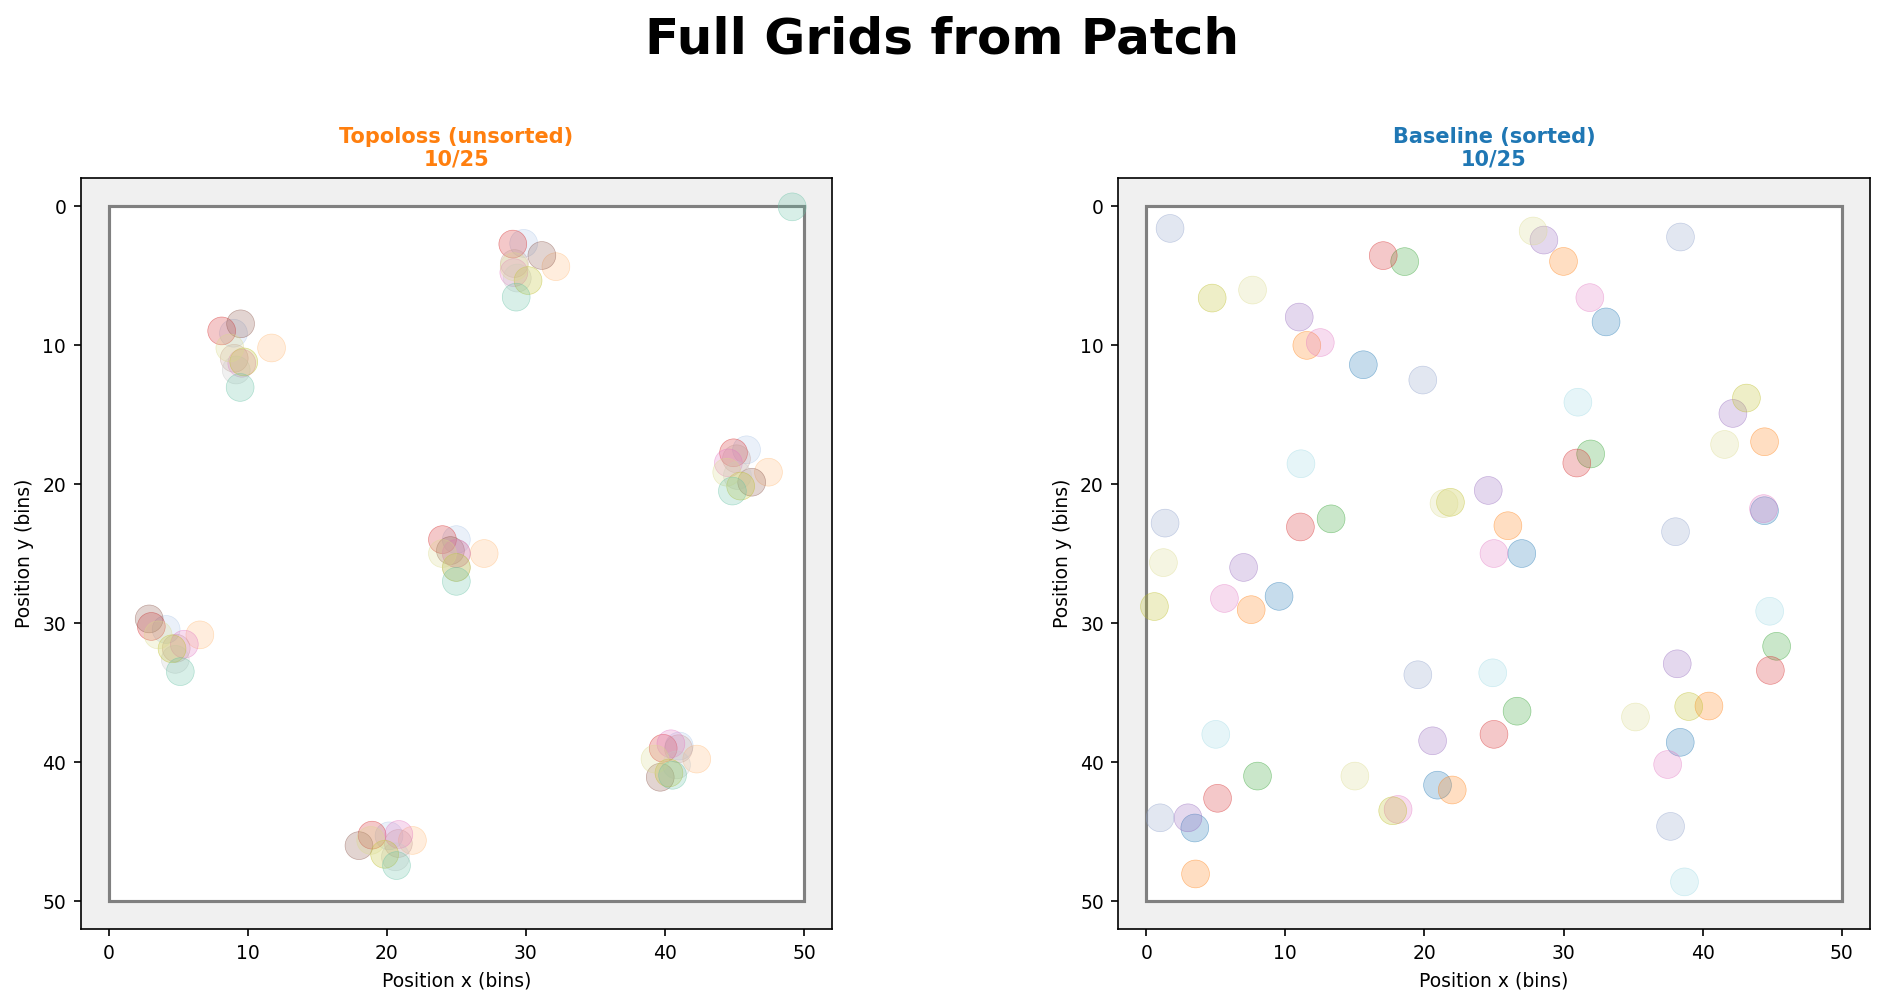

Topoloss (unsorted)
 Patch Pos  Neuron  Grid Score  Orientation (degrees)  Scale (pixels)  Phase dx  Phase dy
  (-2, -1)    1032       1.366        42.8        21.8         0        -1
  (-2, +1)    1034       1.318        44.0        21.3         2         0
  (-1, -1)    1096       1.481        43.4        21.8        -1        -1
  (+0, -2)    1159       1.320        47.2        22.2        -7        21
  (+0, -1)    1160       1.380        41.3        21.3         0         0
  (+0, +0)    1161       1.338        41.6        20.6         0         0
  (+1, -2)    1223       1.331        41.9        21.3         0         1
  (+1, -1)    1224       1.335        44.0        21.3         0         1
  (+1, +0)    1225       1.324        44.0        21.3        -1         0
  (+2, -2)    1287       1.315        41.9        20.9         0         2

Orientation: mean=43.2 degrees, std=1.7 degrees
Scale: mean=21.4 pixels, std=0.4 pixels
Baseline (sorted)
 Patch Pos  Neuron  Grid Score  O

In [7]:
MIN_GRID_SCORE = 0.9
BLOB_RADIUS = 1
N_NEURONS = 10 # Overrides min grid score if nonzero

import cv2
import scipy.signal as sp_sig
from matplotlib import gridspec
from matplotlib.patches import Circle
from scipy.ndimage import maximum_filter

patch_size = 5
mid = patch_size // 2

def _compute_sac_full(rm):
    c = rm - rm.mean()
    sac = sp_sig.fftconvolve(c, c[::-1, ::-1], mode='full')
    return sac / (np.abs(sac).max() + 1e-10)

def _extract_grid_params(sac):
    """
    Returns orientation and scale
    """
    ny, nx = sac.shape
    cy, cx = ny // 2, nx // 2
    
    Y, X = np.ogrid[:ny, :nx]
    r = np.sqrt((X - cx)**2 + (Y - cy)**2)
    center_mask_r = min(cy, cx) * 0.18
    outer_mask_r = min(cy, cx) * 0.85
    
    sac_masked = sac.copy()
    sac_masked[r < center_mask_r] = 0
    sac_masked[r > outer_mask_r] = 0
    
    neighborhood = maximum_filter(sac_masked, size=7)
    peaks = (sac_masked == neighborhood) & (sac_masked > 0.15)
    peak_ys, peak_xs = np.where(peaks)
    
    if len(peak_ys) < 3:
        peaks = (sac_masked == neighborhood) & (sac_masked > 0.05)
        peak_ys, peak_xs = np.where(peaks)
    
    if len(peak_ys) < 3:
        return 0.0, 10.0
    
    dists = np.sqrt((peak_xs - cx)**2 + (peak_ys - cy)**2)
    order = np.argsort(dists)
    
    n_ring = min(6, len(order))
    ring_idx = order[:n_ring]
    ring_x = peak_xs[ring_idx] - cx
    ring_y = peak_ys[ring_idx] - cy
    ring_dists = dists[ring_idx]
    
    scale = np.median(ring_dists)
    
    angles = np.arctan2(ring_y, ring_x)
    angles = angles % (2 * np.pi)
    angles_60 = angles % (np.pi / 3)
    orientation = np.median(angles_60)
    
    return orientation, scale

def _extract_phase_offset(rm, center_rm):
    """
    Returns phase in x and y
    """
    c1 = center_rm - center_rm.mean()
    c2 = rm - rm.mean()
    xcorr = sp_sig.fftconvolve(c1, c2[::-1, ::-1], mode='same')
    res = rm.shape[0]
    pk = np.unravel_index(np.argmax(xcorr), xcorr.shape)
    dx = -(pk[1] - res // 2)
    dy = -(pk[0] - res // 2)
    return dx, dy

def _generate_hex_centers(orientation, scale, phase_dx, phase_dy, extent=55):
    """
    Generate full hexagonal grid given phase, scale, orientation
    """
    a1 = scale * np.array([np.cos(orientation), np.sin(orientation)])
    a2 = scale * np.array([np.cos(orientation + np.pi / 3),
                           np.sin(orientation + np.pi / 3)])
    
    n_max = int(np.ceil(extent / scale)) + 3
    centers = []
    cx, cy = extent / 2 + phase_dx, extent / 2 + phase_dy
    for i in range(-n_max, n_max + 1):
        for j in range(-n_max, n_max + 1):
            pt = np.array([cx, cy]) + i * a1 + j * a2
            if -scale < pt[0] < extent + scale and -scale < pt[1] < extent + scale:
                centers.append(pt)
    return centers

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

cmap_neurons = plt.cm.tab20(np.linspace(0, 1, 20))
extra_5 = plt.cm.Set2(np.linspace(0, 1, 8))[:5]
neuron_colors = np.vstack([cmap_neurons, extra_5])

env_size = 50

model_tables = []

for col, (model_label, patches, scores, act, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, "C1"),
    ("Baseline (sorted)", baseline_patches, baseline_score60_sorted, baseline_act_sorted, "C0"),
]):
    ax = axes[col]
    cy, cx = patches[1] # Chosen patch
    
    neurons = []
    rms = []
    patch_positions = []
    for di in range(patch_size):
        for dj in range(patch_size):
            ri = (cy - mid + di) % n
            ci = (cx - mid + dj) % n
            neurons.append(ri * n + ci)
            rm = cv2.GaussianBlur(act[ri * n + ci], (3, 3), sigmaX=1, sigmaY=1)
            rms.append(rm)
            patch_positions.append((di - mid, dj - mid))
    
    # Determines neurons to plot
    neuron_scores = np.array([scores[nidx] for nidx in neurons])
    if N_NEURONS > 0:
        top_k = np.argsort(neuron_scores)[::-1][:N_NEURONS]
        plot_set = set(top_k.tolist())
    else:
        plot_set = set(k for k in range(len(neurons)) if neuron_scores[k] >= MIN_GRID_SCORE)
    
    center_idx = mid * patch_size + mid
    center_rm = rms[center_idx]
    
    ax.set_facecolor('#f0f0f0')
    ax.set_xlim(-2, env_size + 2)
    ax.set_ylim(env_size + 2, -2)
    ax.set_aspect('equal')
    ax.add_patch(plt.Rectangle((0, 0), env_size, env_size,
                               facecolor='white', edgecolor='gray',
                               linewidth=1.5, zorder=0))
    
    # Overlay each neuron's "full/perfect" grid and collect stats
    table_rows = []
    for k in range(len(neurons)):
        if k not in plot_set:
            continue
        
        rm_k = rms[k]
        
        sac_k = _compute_sac_full(rm_k)
        orient_k, scale_k = _extract_grid_params(sac_k)
        
        if k == center_idx:
            pdx, pdy = 0, 0
        else:
            pdx, pdy = _extract_phase_offset(rm_k, center_rm)
        
        centers = _generate_hex_centers(orient_k, scale_k, pdx, pdy,
                                        extent=env_size)
        
        c_rgba = list(neuron_colors[k][:3]) + [0.25]
        for (gx, gy) in centers:
            if 0 <= gx <= env_size and 0 <= gy <= env_size:
                circle = Circle((gx, gy), BLOB_RADIUS,
                                facecolor=c_rgba,
                                edgecolor=list(neuron_colors[k][:3]) + [0.5],
                                linewidth=0.3, zorder=2)
                ax.add_patch(circle)
        
        di_rel, dj_rel = patch_positions[k]
        table_rows.append({
            'patch_pos': f"({di_rel:+d}, {dj_rel:+d})",
            'neuron_idx': neurons[k],
            'grid_score': neuron_scores[k],
            'orientation_deg': np.degrees(orient_k),
            'scale_px': scale_k,
            'phase_dx': pdx,
            'phase_dy': pdy,
        })
    
    model_tables.append((model_label, table_rows))
    
    ax.set_title(f"{model_label}\n"
                 f"{len(plot_set)}/25",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Position x (bins)', fontsize=9)
    ax.set_ylabel('Position y (bins)', fontsize=9)

fig.suptitle(
    "Full Grids from Patch",
    fontsize=24, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Print stats
for model_label, rows in model_tables:
    print(f"{model_label}")
    print(f"{'Patch Pos':>10s}  {'Neuron':>6s}  {'Grid Score':>10s}  "
          f"{'Orientation (degrees)':>10s}  {'Scale (pixels)':>10s}  "
          f"{'Phase dx':>8s}  {'Phase dy':>8s}")
    for r in rows:
        print(f"{r['patch_pos']:>10s}  {r['neuron_idx']:>6d}  {r['grid_score']:>10.3f}  "
              f"{r['orientation_deg']:>10.1f}  {r['scale_px']:>10.1f}  "
              f"{r['phase_dx']:>8d}  {r['phase_dy']:>8d}")
    # Summary stats
    orients = [r['orientation_deg'] for r in rows]
    scales = [r['scale_px'] for r in rows]
    print(f"\nOrientation: mean={np.mean(orients):.1f} degrees, std={np.std(orients):.1f} degrees")
    print(f"Scale: mean={np.mean(scales):.1f} pixels, std={np.std(scales):.1f} pixels")

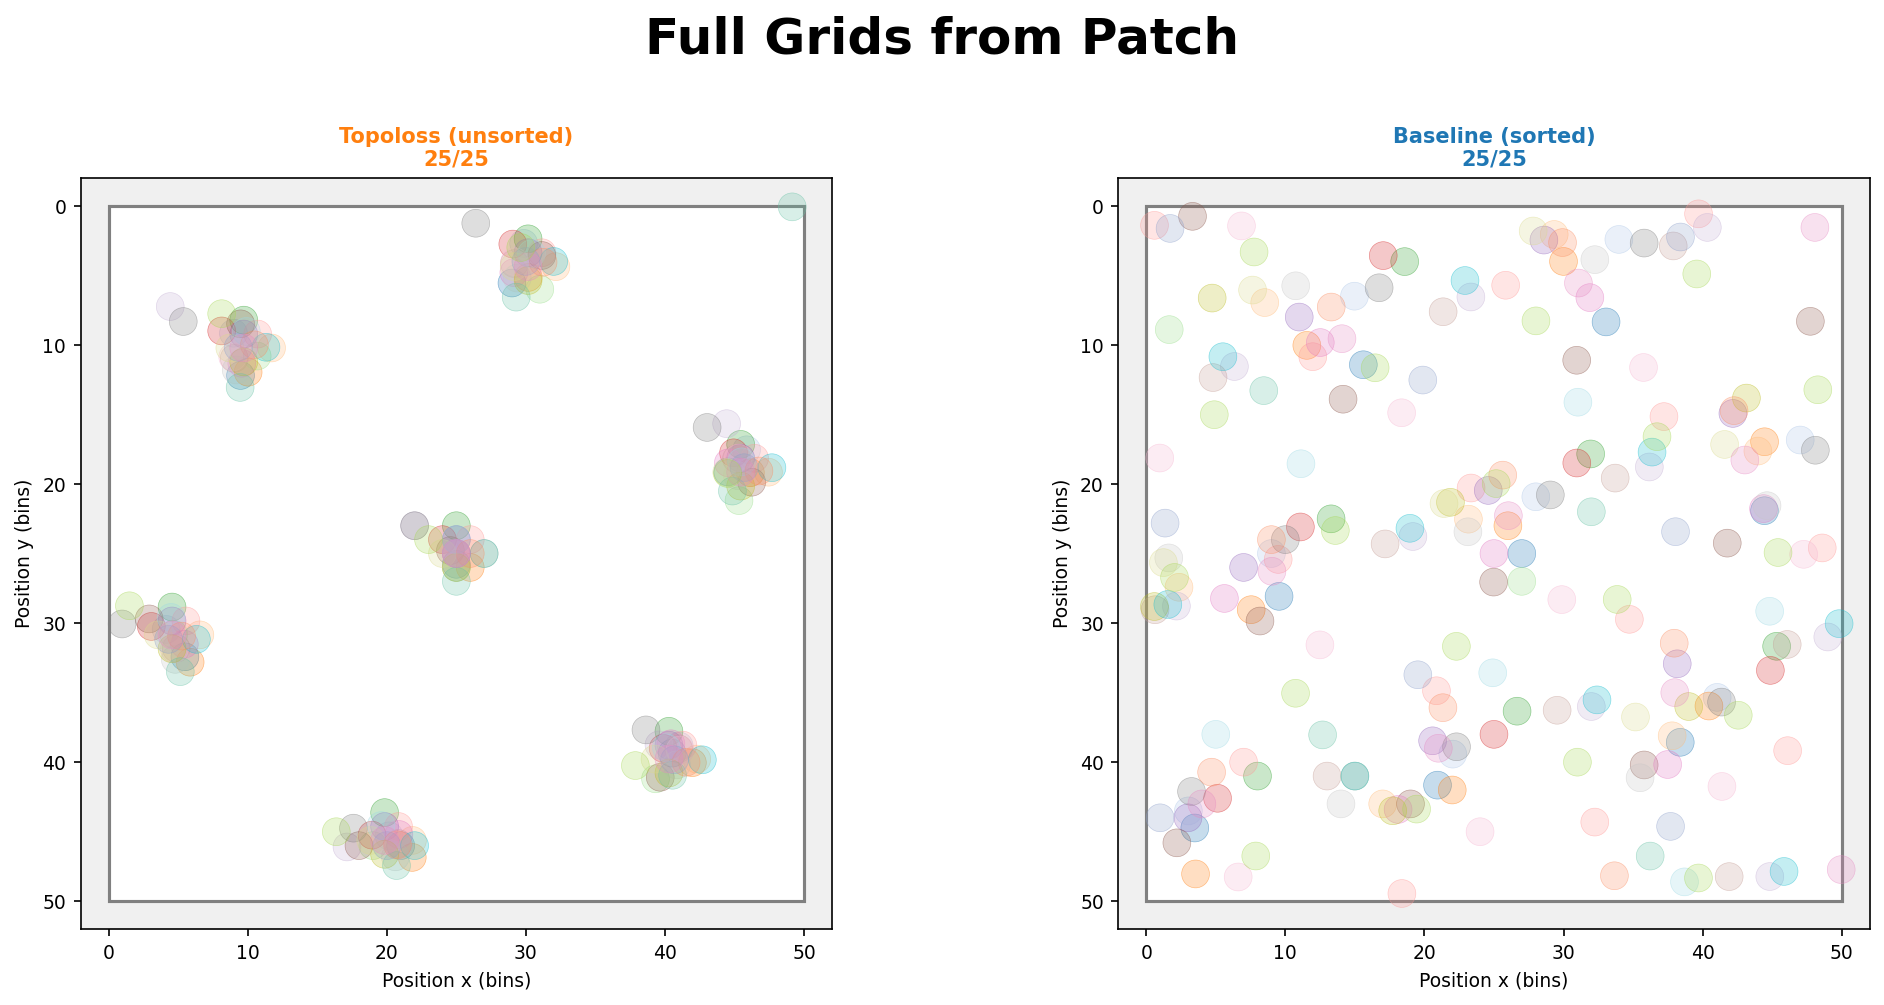

Topoloss (unsorted)
 Patch Pos  Neuron  Grid Score  Orientation (degrees)  Scale (pixels)  Phase dx  Phase dy
  (-2, -2)    1031       0.957        41.2        20.6        -4        21
  (-2, -1)    1032       1.366        42.8        21.8         0        -1
  (-2, +0)    1033       1.168        41.3        21.3         1         1
  (-2, +1)    1034       1.318        44.0        21.3         2         0
  (-2, +2)    1035       1.116        44.0        21.3         0        -2
  (-1, -2)    1095       1.038        46.7        20.9         0         1
  (-1, -1)    1096       1.481        43.4        21.8        -1        -1
  (-1, +0)    1097       1.296        44.0        21.3         1        -1
  (-1, +1)    1098       1.312        44.0        21.3         0        -1
  (-1, +2)    1099       0.836        41.9        23.6        -3        -2
  (+0, -2)    1159       1.320        47.2        22.2        -7        21
  (+0, -1)    1160       1.380        41.3        21.3         0 

In [8]:
MIN_GRID_SCORE = 0.9
BLOB_RADIUS = 1
N_NEURONS = 25 # Overrides min grid score if nonzero

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

cmap_neurons = plt.cm.tab20(np.linspace(0, 1, 20))
extra_5 = plt.cm.Set2(np.linspace(0, 1, 8))[:5]
neuron_colors = np.vstack([cmap_neurons, extra_5])

env_size = 50

model_tables = []

for col, (model_label, patches, scores, act, color) in enumerate([
    ("Topoloss (unsorted)", topo_patches, topo_score60, topo_act, "C1"),
    ("Baseline (sorted)", baseline_patches, baseline_score60_sorted, baseline_act_sorted, "C0"),
]):
    ax = axes[col]
    cy, cx = patches[1] # Chosen patch
    
    neurons = []
    rms = []
    patch_positions = []
    for di in range(patch_size):
        for dj in range(patch_size):
            ri = (cy - mid + di) % n
            ci = (cx - mid + dj) % n
            neurons.append(ri * n + ci)
            rm = cv2.GaussianBlur(act[ri * n + ci], (3, 3), sigmaX=1, sigmaY=1)
            rms.append(rm)
            patch_positions.append((di - mid, dj - mid))
    
    # Determines neurons to plot
    neuron_scores = np.array([scores[nidx] for nidx in neurons])
    if N_NEURONS > 0:
        top_k = np.argsort(neuron_scores)[::-1][:N_NEURONS]
        plot_set = set(top_k.tolist())
    else:
        plot_set = set(k for k in range(len(neurons)) if neuron_scores[k] >= MIN_GRID_SCORE)
    
    center_idx = mid * patch_size + mid
    center_rm = rms[center_idx]
    
    ax.set_facecolor('#f0f0f0')
    ax.set_xlim(-2, env_size + 2)
    ax.set_ylim(env_size + 2, -2)
    ax.set_aspect('equal')
    ax.add_patch(plt.Rectangle((0, 0), env_size, env_size,
                               facecolor='white', edgecolor='gray',
                               linewidth=1.5, zorder=0))
    
    # Overlay each neuron's "full/perfect" grid and collect stats
    table_rows = []
    for k in range(len(neurons)):
        if k not in plot_set:
            continue
        
        rm_k = rms[k]
        
        sac_k = _compute_sac_full(rm_k)
        orient_k, scale_k = _extract_grid_params(sac_k)
        
        if k == center_idx:
            pdx, pdy = 0, 0
        else:
            pdx, pdy = _extract_phase_offset(rm_k, center_rm)
        
        centers = _generate_hex_centers(orient_k, scale_k, pdx, pdy,
                                        extent=env_size)
        
        c_rgba = list(neuron_colors[k][:3]) + [0.25]
        for (gx, gy) in centers:
            if 0 <= gx <= env_size and 0 <= gy <= env_size:
                circle = Circle((gx, gy), BLOB_RADIUS,
                                facecolor=c_rgba,
                                edgecolor=list(neuron_colors[k][:3]) + [0.5],
                                linewidth=0.3, zorder=2)
                ax.add_patch(circle)
        
        di_rel, dj_rel = patch_positions[k]
        table_rows.append({
            'patch_pos': f"({di_rel:+d}, {dj_rel:+d})",
            'neuron_idx': neurons[k],
            'grid_score': neuron_scores[k],
            'orientation_deg': np.degrees(orient_k),
            'scale_px': scale_k,
            'phase_dx': pdx,
            'phase_dy': pdy,
        })
    
    model_tables.append((model_label, table_rows))
    
    ax.set_title(f"{model_label}\n"
                 f"{len(plot_set)}/25",
                 fontsize=10, fontweight='bold', color=color)
    ax.set_xlabel('Position x (bins)', fontsize=9)
    ax.set_ylabel('Position y (bins)', fontsize=9)

fig.suptitle(
    "Full Grids from Patch",
    fontsize=24, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

# Print stats
for model_label, rows in model_tables:
    print(f"{model_label}")
    print(f"{'Patch Pos':>10s}  {'Neuron':>6s}  {'Grid Score':>10s}  "
          f"{'Orientation (degrees)':>10s}  {'Scale (pixels)':>10s}  "
          f"{'Phase dx':>8s}  {'Phase dy':>8s}")
    for r in rows:
        print(f"{r['patch_pos']:>10s}  {r['neuron_idx']:>6d}  {r['grid_score']:>10.3f}  "
              f"{r['orientation_deg']:>10.1f}  {r['scale_px']:>10.1f}  "
              f"{r['phase_dx']:>8d}  {r['phase_dy']:>8d}")
    # Summary stats
    orients = [r['orientation_deg'] for r in rows]
    scales = [r['scale_px'] for r in rows]
    print(f"\nOrientation: mean={np.mean(orients):.1f} degrees, std={np.std(orients):.1f} degrees")
    print(f"Scale: mean={np.mean(scales):.1f} pixels, std={np.std(scales):.1f} pixels")